# **Connect to GEE**

In [1]:
!pip install -q --upgrade --pre xee
!pip install -q -U geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 67.9 MB/s eta 0:00:00


In [2]:
import ee

In [3]:
ee.Authenticate()
ee.Initialize(
    project = 'ee-amirhosseinahrari',
    opt_url = 'https://earthengine-highvolume.googleapis.com'
)

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


# **Study Area**

In [4]:
import geemap

In [5]:
hansen = (
    ee.Image("UMD/hansen/global_forest_change_2025_v1_13")
)

In [6]:
wildfire = (
    hansen.select('loss').eq(1).And(
        hansen.select('lossyear').eq(23)
    )
)

In [7]:
map = geemap.Map(basemap = 'SATELLITE')
map.addLayer(wildfire, {},'wildfire23')
map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [8]:
roi = map.draw_last_feature.geometry()
roi

ee.Geometry({
  "functionInvocationValue": {
    "functionName": "Feature.geometry",
    "arguments": {
      "feature": {
        "functionInvocationValue": {
          "functionName": "Feature",
          "arguments": {
            "geometry": {
              "functionInvocationValue": {
                "functionName": "GeometryConstructors.Polygon",
                "arguments": {
                  "coordinates": {
                    "constantValue": [
                      [
                        [
                          -123.678589,
                          57.932351
                        ],
                        [
                          -123.678589,
                          58.165632
                        ],
                        [
                          -123.204803,
                          58.165632
                        ],
                        [
                          -123.204803,
                          57.932351
                        ],
                        [
                          -123.678589,
                          57.932351
                        ]
                      ]
                    ]
                  },
                  "geodesic": {
                    "constantValue": false
                  }
                }
              }
            }
          }
        }
      }
    }
  }
})

# **Landsat Image Collection**

In [9]:
landsat8 = (
    ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
    .filterDate('2022','2025')
    .filterBounds(roi)
    .filter(ee.Filter.lt('CLOUD_COVER', 20))
)

In [11]:
landsat9 = (
    ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")
    .filterDate('2022','2025')
    .filterBounds(roi)
    .filter(ee.Filter.lt('CLOUD_COVER',20))
)

In [13]:
landsat = landsat8.merge(landsat9).sort('system:time_start')

In [15]:
def ndvi(img):
  qa_band = img.select('QA_PIXEL')
  bit1 = qa_band.bitwiseAnd(1 << 1).neq(0)
  bit2 = qa_band.bitwiseAnd(1 << 2).neq(0)
  bit3 = qa_band.bitwiseAnd(1 << 3).neq(0)
  bit4 = qa_band.bitwiseAnd(1 << 4).neq(0)
  mask = bit1.Or(bit2).Or(bit3).Or(bit4)
  sr = img.select('SR_B.*').multiply(2.75e-05).add(-0.2)
  index = sr.normalizedDifference(['SR_B5','SR_B4']).rename('ndvi')
  return index.updateMask(mask.Not()).copyProperties(img, ['system:time_start'])

In [16]:
landsat_ndvi = landsat.map(ndvi)

# **to Xarray**

In [18]:
import xarray as xr
from shapely.geometry import shape
from xee import helpers

In [19]:
landsat8.first().select('SR_B1').projection()

In [20]:
grid = helpers.fit_geometry(
    geometry = shape(roi.getInfo()),
    grid_crs = 'EPSG:32610',
    grid_scale = (30, -30)
)

In [21]:
ds = xr.open_dataset(
    landsat_ndvi,
    engine = 'ee',
    **grid
)

In [23]:
ds = ds.sortby('time') * 1

# **Wildfire Change Detection**

In [31]:
prefire = ds.sel(time = '2022').mean(dim = 'time')
postfire = ds.sel(time = '2024').mean(dim = 'time')
change = prefire - postfire

In [33]:
from skimage.filters import threshold_otsu

In [37]:
change_val = change.ndvi.values

In [38]:
change_thr = threshold_otsu(change_val)

In [39]:
change_thr

np.float32(0.2627452)

In [40]:
fire_mask = (change.ndvi >= change_thr).astype(int)

In [42]:
from skimage.morphology import remove_small_objects

In [46]:
mask_val = fire_mask.values.astype(bool)
mask_cor = remove_small_objects(mask_val)
mask_cor = xr.DataArray(
    mask_cor,
    dims = fire_mask.dims,
    coords = fire_mask.coords
)

In [25]:
import matplotlib.pyplot as plt

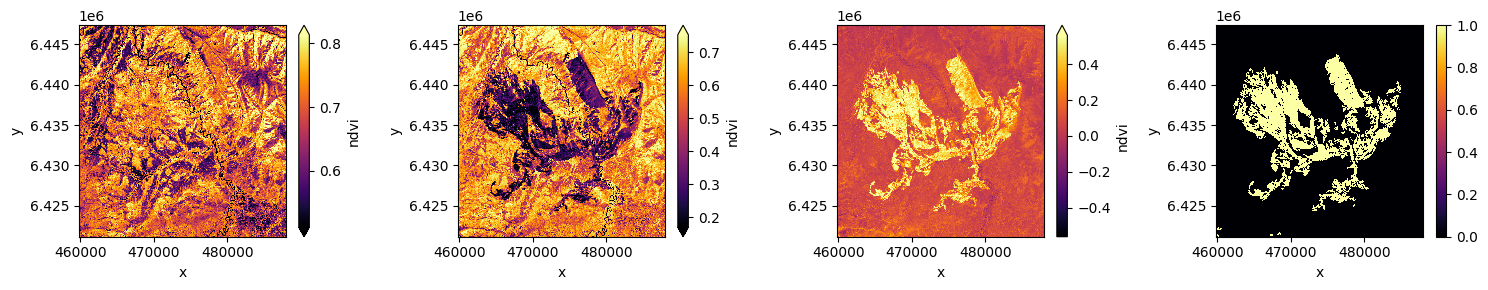

In [48]:
fig, ax = plt.subplots(1, 4, figsize = (15, 3))

prefire.ndvi.plot(ax = ax[0], robust =True, cmap = 'inferno')
postfire.ndvi.plot(ax = ax[1], robust = True, cmap = 'inferno')
change.ndvi.plot(ax = ax[2], robust = True, cmap = 'inferno')
mask_cor.plot(ax =ax[3], cmap = 'inferno')

plt.tight_layout()

plt.savefig('wildfire.png', dpi = 360, bbox_inches = 'tight')

# **Area Calculation**

In [50]:
(mask_cor == 1).astype(int).sum(dim = ['y','x']).item() * ((30 * 30) / 1e6)

127.1349